In [38]:
# import libraries

# Data Analysis Libraries
import pandas as pd 
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [39]:
# Load the dataset
try:
    df = pd.read_csv("day_04_student_performance_prediction_dataset.csv")
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: The dataset file was not found. Please check the file path and try again.")

Error: The dataset file was not found. Please check the file path and try again.


### Understanding the dataset

In [40]:
df.head()

,student_id,student_name,age,gender,course,attendance,assignment_score,midterm_score,final_score,result
0,S001,Ali,23,Male,Artificial Intelligence,51,87,70,61,1
1,S002,Fatima,19,Female,Data Science,97,46,46,84,1
2,S003,Bilal,18,Male,Artificial Intelligence,55,53,64,94,1
3,S004,Hina,22,Female,Artificial Intelligence,85,52,88,58,1
4,S005,Hamza,21,Male,Cyber Security,50,88,55,84,1


In [41]:
df.tail()

,student_id,student_name,age,gender,course,attendance,assignment_score,midterm_score,final_score,result
95,S096,Amna,21,Female,Software Engineering,60,87,95,87,1
96,S097,Farhan,20,Male,Data Science,90,57,97,60,1
97,S098,Komal,20,Female,Software Engineering,54,85,71,60,1
98,S099,Owais,20,Male,Cyber Security,70,97,45,47,0
99,S100,Nimra,19,Female,Data Science,74,84,54,57,1


In [42]:
df.sample(5)

,student_id,student_name,age,gender,course,attendance,assignment_score,midterm_score,final_score,result
65,S066,Noor,23,Female,Data Science,84,42,82,100,1
9,S010,Maham,23,Female,Artificial Intelligence,52,82,64,67,1
71,S072,Sana,20,Female,Data Science,100,84,48,78,1
92,S093,Adnan,24,Male,Software Engineering,64,51,94,36,0
4,S005,Hamza,21,Male,Cyber Security,50,88,55,84,1


In [43]:
df.shape

(100, 10)

In [44]:
df.columns

Index(['student_id', 'student_name', 'age', 'gender', 'course', 'attendance',
       'assignment_score', 'midterm_score', 'final_score', 'result'],
      dtype='str')

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   student_id        100 non-null    str  
 1   student_name      100 non-null    str  
 2   age               100 non-null    int64
 3   gender            100 non-null    str  
 4   course            100 non-null    str  
 5   attendance        100 non-null    int64
 6   assignment_score  100 non-null    int64
 7   midterm_score     100 non-null    int64
 8   final_score       100 non-null    int64
 9   result            100 non-null    int64
dtypes: int64(6), str(4)
memory usage: 7.9 KB


In [46]:
df.describe()

,age,attendance,assignment_score,midterm_score,final_score,result
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,21.190000,73.580000,68.740000,66.890000,64.490000,0.730000
std,1.993398,15.738507,17.134418,19.217992,19.804854,0.446196
min,18.000000,50.000000,40.000000,35.000000,30.000000,0.000000
25%,20.000000,58.750000,55.000000,50.750000,46.250000,0.000000
50%,21.000000,72.000000,67.000000,64.000000,61.000000,1.000000
75%,23.000000,88.250000,82.500000,86.000000,81.000000,1.000000
max,24.000000,100.000000,99.000000,100.000000,100.000000,1.000000


In [47]:
# check missing values
df.isnull().sum()

student_id          0
student_name        0
age                 0
gender              0
course              0
attendance          0
assignment_score    0
midterm_score       0
final_score         0
result              0
dtype: int64

In [48]:
# check duplicates values
df.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
95    False
96    False
97    False
98    False
99    False
Length: 100, dtype: bool

In [49]:
# Check data types
df.dtypes

student_id            str
student_name          str
age                 int64
gender                str
course                str
attendance          int64
assignment_score    int64
midterm_score       int64
final_score         int64
result              int64
dtype: object

In [50]:
# Rename the columns
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)
df.columns

Index(['student_id', 'student_name', 'age', 'gender', 'course', 'attendance',
       'assignment_score', 'midterm_score', 'final_score', 'result'],
      dtype='str')

In [51]:
# Exploratory Data Analysis (EDA)
df["course"].value_counts()

course
Cyber Security             28
Artificial Intelligence    25
Data Science               25
Software Engineering       22
Name: count, dtype: int64

In [52]:
df["attendance"].value_counts()

attendance
58     6
93     5
55     4
59     4
60     4
82     4
100    4
85     3
50     3
56     3
90     3
63     3
57     3
87     3
72     3
51     2
97     2
52     2
94     2
70     2
74     2
69     2
95     2
54     2
80     2
66     2
73     2
89     2
67     2
92     2
79     2
96     1
99     1
88     1
83     1
71     1
76     1
84     1
61     1
75     1
77     1
65     1
64     1
98     1
Name: count, dtype: int64

In [53]:
df["gender"].value_counts()

gender
Male      50
Female    50
Name: count, dtype: int64

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   student_id        100 non-null    str  
 1   student_name      100 non-null    str  
 2   age               100 non-null    int64
 3   gender            100 non-null    str  
 4   course            100 non-null    str  
 5   attendance        100 non-null    int64
 6   assignment_score  100 non-null    int64
 7   midterm_score     100 non-null    int64
 8   final_score       100 non-null    int64
 9   result            100 non-null    int64
dtypes: int64(6), str(4)
memory usage: 7.9 KB


In [55]:
# separating numerical features
numerical_features = [
    "age",
    "attendance",
    "assignment_score",
    "midterm_score",
    "final_score"
]

In [56]:
# separating categorical features
categorical_features = [
    "gender",
    "course"
]

### Creating pipeline separtely for each numerical and categorical columns

In [57]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [58]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

#### Combine Both Pipeline

In [59]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

At this point:

Numerical columns → Missing values filled → Standardized

Categorical columns → Missing values filled → One-Hot Encoded

In [60]:
df.columns

Index(['student_id', 'student_name', 'age', 'gender', 'course', 'attendance',
       'assignment_score', 'midterm_score', 'final_score', 'result'],
      dtype='str')

In [61]:
# Separate Features and Target

X = df.drop(columns=["student_id","student_name","result"])
y = df["result"]

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    #random_state=42,
    stratify=y
)

#### Build Complete Pipeline

In [76]:
lr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression())
    ]
)

In [77]:
# train the model 
lr_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['age','gender','course',...,'assignment_score','midterm_score', 'final_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrou

In [78]:
y_pred = lr_model.predict(X_test)

In [79]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 100.00%


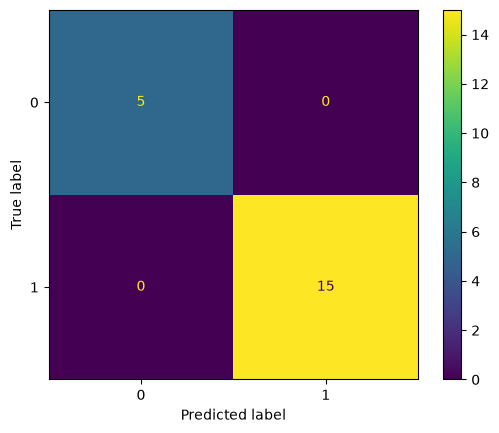

In [67]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()

plt.show()

In [68]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        15

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



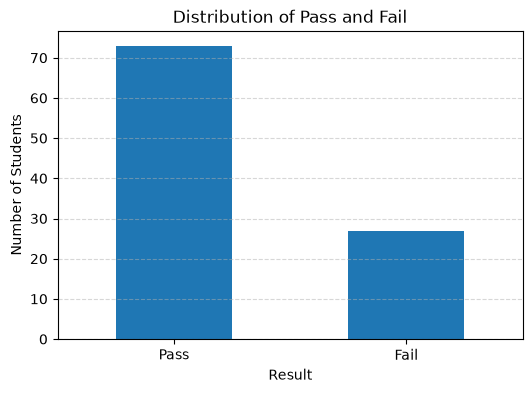

In [72]:
# Distribution of Pass vs Fail
 
plt.figure(figsize=(6, 4))

df["result"].value_counts().plot(kind="bar")

plt.title("Distribution of Pass and Fail")
plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.xticks([0, 1], ["Pass", "Fail"], rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

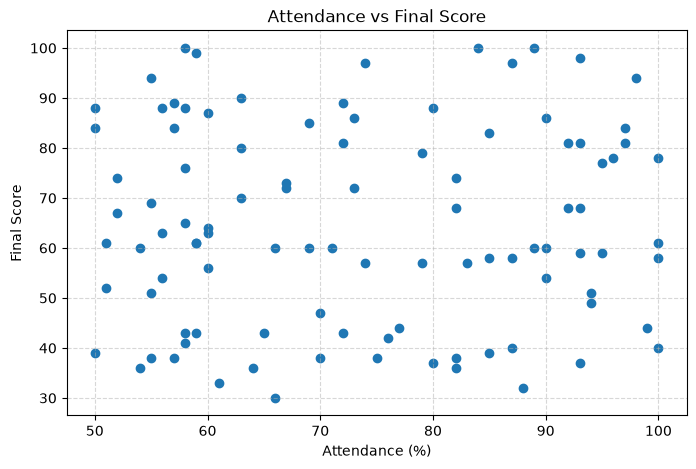

In [70]:
# Attendance vs Final Score 

plt.figure(figsize=(8, 5))

plt.scatter(
    df["attendance"],
    df["final_score"]
)

plt.title("Attendance vs Final Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

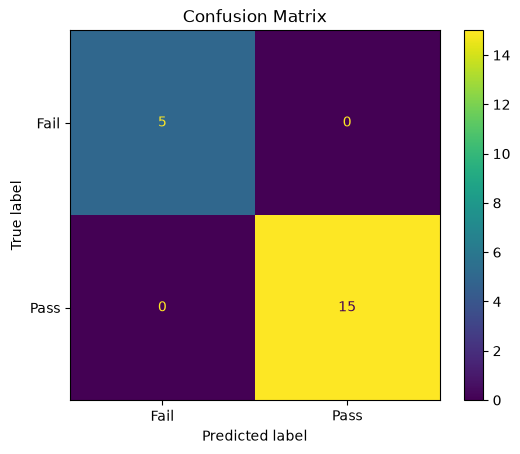

In [71]:
cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

display.plot()

plt.title("Confusion Matrix")

plt.show()

### Decision Tree Pipeline

In [73]:
# split the dataset
X_train

X_test

y_train

y_test

6     1
16    1
48    1
18    1
71    1
24    1
11    1
77    1
19    0
1     1
0     1
66    1
91    0
82    1
64    0
4     1
78    0
28    1
33    0
20    1
Name: result, dtype: int64

In [74]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42,
            max_depth=5
        ))
    ]
)

In [75]:
decision_tree_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['age','gender','course',...,'assignment_score','midterm_score', 'final_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthro

In [80]:
lr_prediction = lr_model.predict(X_test)

dt_prediction = decision_tree_pipeline.predict(X_test)

In [81]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(y_true, y_pred)

    recall = recall_score(y_true, y_pred)

    f1 = f1_score(y_true, y_pred)

    print(f"\n{model_name}")

    print(f"Accuracy : {accuracy:.3f}")

    print(f"Precision: {precision:.3f}")

    print(f"Recall   : {recall:.3f}")

    print(f"F1 Score : {f1:.3f}")

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

In [82]:
lr_result = evaluate_model(
    "Logistic Regression",
    y_test,
    lr_prediction
)

dt_result = evaluate_model(
    "Decision Tree",
    y_test,
    dt_prediction
)


Logistic Regression
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1 Score : 1.000

Decision Tree
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1 Score : 1.000


In [83]:
comparison = pd.DataFrame([
    lr_result,
    dt_result
])

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0


In [84]:
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_matrix(model, X_test, y_test):

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test
    )

    plt.show()

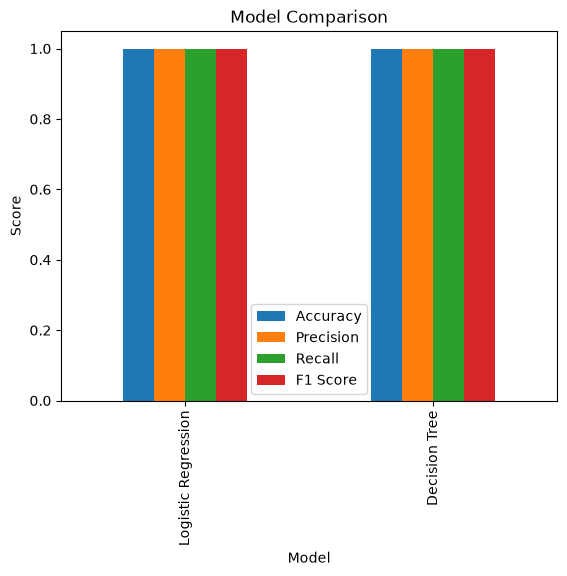

In [85]:
comparison.set_index("Model")[
    ["Accuracy","Precision","Recall","F1 Score"]
].plot(kind="bar")

plt.title("Model Comparison")

plt.ylabel("Score")

plt.show()

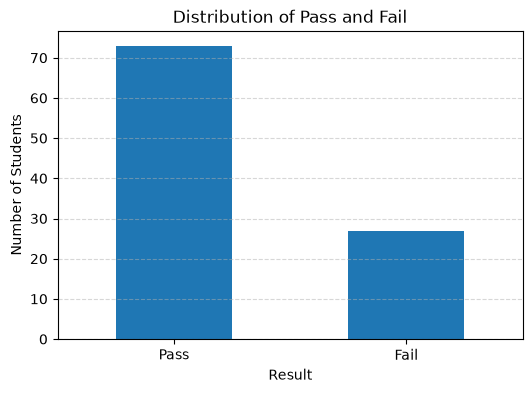

In [86]:
# Distribution of Pass vs Fail
 
plt.figure(figsize=(6, 4))

df["result"].value_counts().plot(kind="bar")

plt.title("Distribution of Pass and Fail")
plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.xticks([0, 1], ["Pass", "Fail"], rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [88]:
print(comparison)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression       1.0        1.0     1.0       1.0
1        Decision Tree       1.0        1.0     1.0       1.0
